# Dynamic Bayesian Networks

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F27-Modele-dynamicBN.ipynb)


Since pyAgrum>=3.2, dynamic Bayesian networks are no longer handled by the pure Python module `pyagrum.lib.dynamicBN`, which is now deprecated. They are handled by `pyagrum.ktbn`, a C++-backed module offering the same modeling capabilities with better performance and native inference on the k-TBN template.

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.dynamicBN as gdyn

/var/folders/r1/pj4vdx_n4_d_xpsb04kzf97r0000gp/T/ipykernel_52995/461012950.py:3: FutureWarning: This module is deprecated since pyAgrum>=3.2. Please use the new c++ enhanced module : 'import pyagrum.ktbn' instead.
  import pyagrum.lib.dynamicBN as gdyn


The table below illustrates how much better dBNs are now supported by this new C++ engine.

| Feature | Description |
|-|-|
| `KTBN` construction | Build a k-TBN directly (`add`, `addArc`, `generateCPTs`) or from an existing KTBN-shaped `BayesNet` (`KTBN.fromBN`) |
| Naming convention | Temporal variables addressed as engine name `"A[t]"` or as the pair `("A", t)` |
| `KTBNInference` | Exact inference run directly on the template, without unrolling, for any horizon `T` |
| Learning | `KTBNGenerator` (random template generation), `KTBNDatabaseGenerator` (sample trajectories to CSV), `KTBNAdaptiveLearner` (learn structure and order `k` from data) |
| Engine | Implemented in C++, replacing the pure Python `pyagrum.lib.dynamicBN` |

In [2]:
import pyagrum.ktbn as gum  # gum+ktbn

### Building a 2TBN

A 2TBN is simply a k-TBN with $k=2$. Following the `pyagrum.ktbn` naming convention, a *temporal* variable named $A$ has one instance per time slice of the template, addressed either as the engine name `A[0]`/`A[1]` or as the pair `("A", 0)`/`("A", 1)`. Slice `0` is the initial slice and slice `1` -- the last of the template -- is the (time-homogeneous) transition kernel, reused for every $t \geq 1$ once unrolled.

However, following the old dynamicBN convention, it is possible to declare a KTBN using a BN with variables name ending with the timeslice (`A0`/`A1`/etc.). Once the ktbn is built, the **true** names of the variable is `A[0]`/`A[1]`/etc.

## 2TBN

In [3]:
# same structure as gum.fastBN("d0[3]->ct<-at<-a0->b0->bt<-a0->dt[3]<-d0<-c0->ct;c0->at", 6)
# but built directly with pyagrum.ktbn : there is (yet) no fast-string constructor for a KTBN
# twodbn = gum.KTBN(2)
# for name in ["a", "b", "c"]:
#  twodbn.add(gum.fastVariable(f"{name}[6]"))
# twodbn.add(gum.fastVariable("d[3]"))

# for base1, s1, base2, s2 in [
#  ("a", 0, "a", 1),
#  ("a", 0, "b", 0),
#  ("a", 0, "b", 1),
#  ("a", 0, "d", 1),
#  ("c", 0, "d", 0),
#  ("c", 0, "c", 1),
#  ("c", 0, "a", 1),
#  ("d", 0, "c", 1),
#  ("d", 0, "d", 1),
#  ("b", 0, "b", 1),
#  ("a", 1, "c", 1),
# ]:
#  twodbn.addArc(base1, s1, base2, s2)
# twodbn.generateCPTs()
bn = gum.fastBN("d0[3]->c1<-a1<-a0->b0->b1<-a0->d1[3]<-d0<-c0->c1;c0->a1", 6)
bn

(pyagrum.BayesNet@0x74b1c68000) BN{nodes: 8, arcs: 11, domainSize: 419904, dim: 988, mem: 9Ko 384o}

Unlike a plain `pyagrum.BayesNet` relying on a naming convention to be recognized as a 2TBN, `KTBN` knows about its two time slices.

k = 2  / arcs = 11


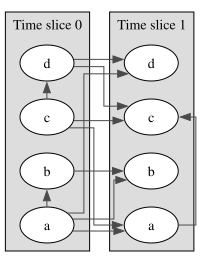

In [4]:
twodbn = gum.KTBN.fromBN(bn)
print("k =", twodbn.k(), " / arcs =", twodbn.sizeArcs())
gnb.show(twodbn)

## unrolling 2TBN

A k-TBN is 'unrolled' using `unroll(T)`, `T` being the number of time slices. For the couple $a[0]$, $a[1]$ in the template, the unrolled BN will include $a[0], a[1], \cdots, a[T-1]$.

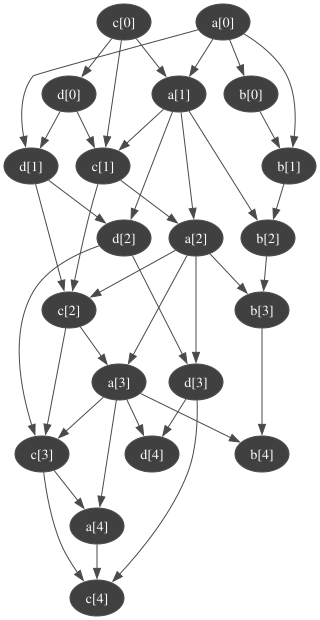

In [5]:
T = 5

bn = twodbn.unroll(T)
gnb.showBN(bn, size="10")

We can infer on `bn` just as on a normal BN. Following the k-TBN engine-name convention, the variables in the unrolled BN are named `base[i]` where `i` is the number of their time slice.


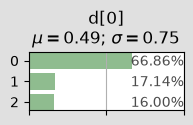
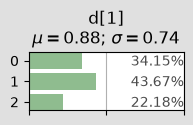
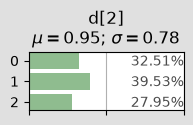
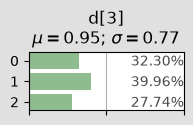
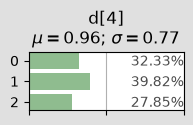

In [6]:
gnb.flow.clear()
for i in range(T):
  gnb.flow.add(gnb.getPosterior(bn, target=f"d[{i}]", evs={}), f"$P(d[{i}])$")
gnb.flow.display()

## dynamic inference : following variables

`gum.KTBNInference` runs exact inference directly on the k-TBN *template* -- without ever unrolling it -- for any horizon `T`. Observations can be placed at any absolute time slice using the engine-name convention (e.g. `"a[9]"`); `posteriors(base)` then returns the whole series $P(base[t] \mid \cdots)$ for $t = 0, \dots, T-1$, which we stack-plot below, just like `gdyn.plotFollow` used to.

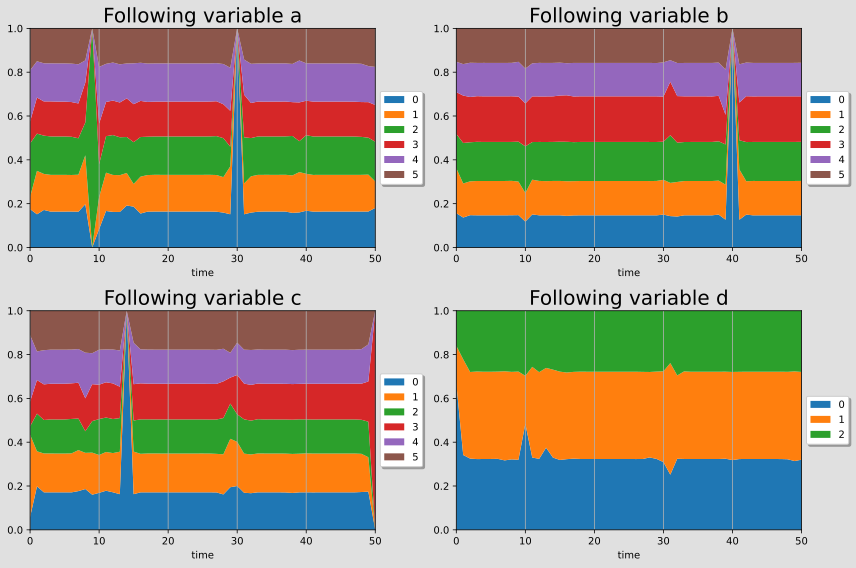

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 2)

gnb.plotFollowKTBN(
  twodbn,
  ["a", "b", "c", "d"],
  T=51,
  observations={"a[9]": 2, "a[30]": 0, "c[14]": 0, "b[40]": 0, "c[50]": 3},
)

## nsDBN (Non-Stationnary Dynamic Bayesian network)

The `pyagrum.ktbn` module does not (yet) model non-stationary dBNs as such : a `KTBN` always assumes the same k-TBN template is reused for every time slice. In the meantime, a non-stationary dBN can still be simulated by unrolling a k-TBN into a plain `pyagrum.BayesNet` with `unroll(T)`, and then editing that unrolled network directly -- changing arcs and CPTs for the time slices where the dynamics differ, as shown below.

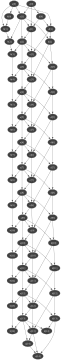

In [8]:
T = 15

bn = twodbn.unroll(T)
gnb.showBN(bn)

Non-stationary dBN allows to express that the dBN does not follow the same 2TBN during all steps. `gum.unroll()` returns a classical `pyagrum.BayesNet`, which can then be changed as you want, exactly as with an unrolled 2TBN before.

In [9]:
##### new P(c[t]|c[t-1])
pot = gum.Tensor().add(twodbn.variable("c", 1)).add(twodbn.variable("c", 0))
pot.fillWith([1, 0, 0, 0.1] * 9).normalizeAsCPT()  # 36 valeurs normalized as CPT

(pyagrum.Tensor@0x74b1f60000) 
      ║  c[1]                                                     │
c[0]  ║0        │1        │2        │3        │4        │5        │
──────║─────────│─────────│─────────│─────────│─────────│─────────│
0     ║ 0.4762  │ 0.0000  │ 0.0000  │ 0.0476  │ 0.4762  │ 0.0000  │
1     ║ 0.0000  │ 0.0833  │ 0.8333  │ 0.0000  │ 0.0000  │ 0.0833  │
2     ║ 0.4762  │ 0.0000  │ 0.0000  │ 0.0476  │ 0.4762  │ 0.0000  │
3     ║ 0.0000  │ 0.0833  │ 0.8333  │ 0.0000  │ 0.0000  │ 0.0833  │
4     ║ 0.4762  │ 0.0000  │ 0.0000  │ 0.0476  │ 0.4762  │ 0.0000  │
5     ║ 0.0000  │ 0.0833  │ 0.8333  │ 0.0000  │ 0.0000  │ 0.0833  │

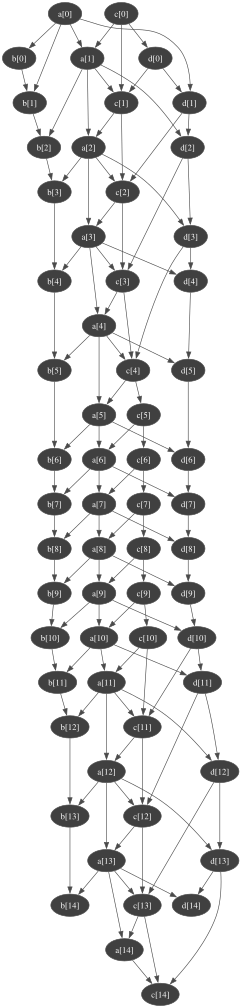

In [10]:
# from steps 5 to 10, C_t only depends on C_{t-1} and follows this new CPT
for i in range(5, 11):
  bn.eraseArc(f"d[{i - 1}]", f"c[{i}]")
  bn.eraseArc(f"a[{i}]", f"c[{i}]")
  bn.cpt(f"c[{i}]").fillWith(pot, ["c[1]", "c[0]"])  # c[1] in pot <- node itself, c[0] in pot <- parent

gnb.showBN(bn, size="14")

Since a non-stationary unrolled BN no longer matches the k-TBN template, `KTBNInference` no longer applies here : we fall back to a plain `LazyPropagation` over the unrolled BN, exactly what `gdyn.plotFollowUnrolled` used to do -- reimplemented locally since `pyagrum.lib.dynamicBN` is retired.

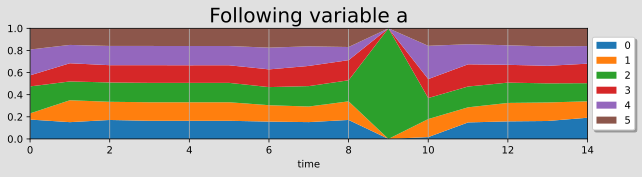

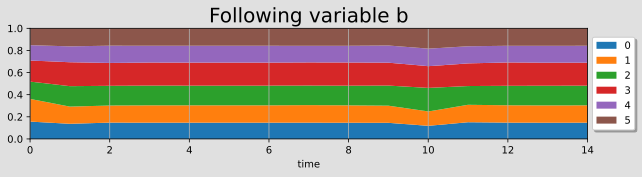

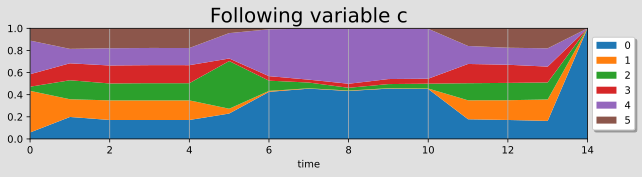

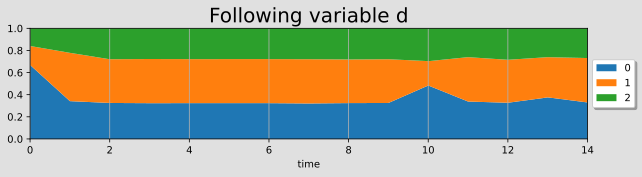

In [11]:
import numpy as np
from matplotlib.patches import Rectangle


def plotFollowUnrolled(lovars, bn, T, evs):
  ie = gum.LazyPropagation(bn)
  ie.setEvidence(evs)
  ie.makeInference()

  x = np.arange(T)
  for var in lovars:
    v0 = bn.variableFromName(f"{var}[0]")
    lpots = []
    for i in range(v0.domainSize()):
      serie = [ie.posterior(bn.idFromName(f"{var}[{t}]"))[i] for t in range(T)]
      lpots.append(serie)

    _, ax = plt.subplots()
    plt.xlim(left=0, right=T - 1)
    plt.ylim(top=1, bottom=0)
    ax.xaxis.grid()
    plt.title(f"Following variable {var}", fontsize=20)
    plt.xlabel("time")

    stack = ax.stackplot(x, lpots)
    proxy_rects = [Rectangle((0, 0), 1, 1, fc=pc.get_facecolor()[0]) for pc in stack]
    labels = [v0.label(i) for i in range(v0.domainSize())]
    plt.legend(proxy_rects, labels, loc="center left", bbox_to_anchor=(1, 0.5), ncol=1, fancybox=True, shadow=True)
    plt.show()


plt.rcParams["figure.figsize"] = (10, 2)
plotFollowUnrolled(["a", "b", "c", "d"], bn, T=15, evs={"a[9]": 2, "c[14]": 0})